# Model C: MIT Sloan 2025 Transformer

이 노트북은 **Model C (MIT Sloan Sports Analytics Conference 2025)**의
핵심 아이디어, 아키텍처, 데이터 처리 흐름, 학습 설정, 결과를 상세히 정리한다.

## 구성

1. 논문 개요
2. 아키텍처
3. 핵심 트릭 1: Sub-token Masking
4. 핵심 트릭 2: Last-pitch Residual
5. 핵심 트릭 3: Multi-task Learning
6. 데이터 파이프라인 (Lazy Loading)
7. 87차원 Feature 분해
8. 10-class 라벨 분포
9. 모델 코드 Walkthrough
10. 학습 설정
11. 결과 (Placeholder)
12. 논문과의 차이점

In [1]:
# 라이브러리 import 및 환경 설정
import sys
import pickle
from pathlib import Path

import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# 프로젝트 루트를 sys.path에 추가
sys.path.insert(0, str(Path('..').resolve()))

from src.models.transformer import PitchTransformer
from src.data.features import PitchResult10

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

print('환경 설정 완료')
print(f'PyTorch: {torch.__version__}')

환경 설정 완료
PyTorch: 2.6.0+cu124


## 1. 논문 개요

### 1.1 기본 정보

| 항목 | 내용 |
|------|------|
| 학회 | MIT Sloan Sports Analytics Conference 2025 |
| 모델 타입 | Transformer Encoder + Multi-task Head |
| 입력 | 400 pitch 시퀀스, 87-dim/pitch |
| 출력 | 24-dim (pitch result 10 + hit location 9 + continuous 5) |

### 1.2 핵심 아이디어

Model B와 달리 **한 타자의 과거 400개 투구 시퀀스**를 Transformer에 입력하여
다음 투구의 결과를 예측한다. 세 가지 트릭이 핵심이다:

1. **Sub-token Masking**: 예측 대상 투구(마지막 pitch)의 결과 피처를 0으로 가려 데이터 누수 방지
2. **Last-pitch Residual**: 마지막 투구 원본 피처를 Transformer 출력에 직접 연결해 정보 희석 보완
3. **Multi-task Learning**: pitch_result + hit_location + continuous 세 가지를 동시 예측

### 1.3 본 프로젝트에서의 기여

논문 재현에 더해 **Lazy Loading** 데이터 파이프라인을 추가 구현했다.
전체 시퀀스를 메모리에 올리면 72 GB가 필요하지만,
lazy loading으로 실제 메모리 사용량을 **1 GB** 수준으로 줄였다.

## 2. 아키텍처

```
입력: (batch, 400, 87)
        ↓
Linear(87 → 256)  ← 입력 임베딩
        ↓
SinusoidalPositionalEncoding(max_len=400, d_model=256)
        ↓
TransformerEncoder × 12
  └─ TransformerEncoderLayer(d_model=256, nhead=8, ff=1024, dropout=0.1)
        ↓
last_encoded = encoder_output[:, -1, :]       # (batch, 256)
last_proj    = Linear(87→256)(input[:, -1, :]) # (batch, 256)  ← Residual
        ↓
concat([last_encoded, last_proj])  → (batch, 512)
        ↓
Linear(512 → 256) + ReLU + Dropout(0.1)
        ↓
Linear(256 → 24)
        ↓
출력: (batch, 24)
  ├─ [:, 0:10]  → pitch_result logits (10-class)
  ├─ [:, 10:19] → hit_location logits (9-class)
  └─ [:, 19:24] → continuous regression (5-dim)
```

C:\Users\zpfh1\AppData\Local\Temp\ipykernel_3264\3139003724.py:50: UserWarning: Glyph 52509 (\N{HANGUL SYLLABLE CONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\zpfh1\AppData\Local\Temp\ipykernel_3264\3139003724.py:50: UserWarning: Glyph 54028 (\N{HANGUL SYLLABLE PA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\zpfh1\AppData\Local\Temp\ipykernel_3264\3139003724.py:50: UserWarning: Glyph 46972 (\N{HANGUL SYLLABLE RA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\zpfh1\AppData\Local\Temp\ipykernel_3264\3139003724.py:50: UserWarning: Glyph 48120 (\N{HANGUL SYLLABLE MI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\zpfh1\AppData\Local\Temp\ipykernel_3264\3139003724.py:50: UserWarning: Glyph 53552 (\N{HANGUL SYLLABLE TEO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\zpfh1\AppData\Local\Temp\ipykernel_3264\3139003724.py:50: UserWarning: Glyph 47560 (\N{HANGUL SYLLABLE MA}) missing from font(s)

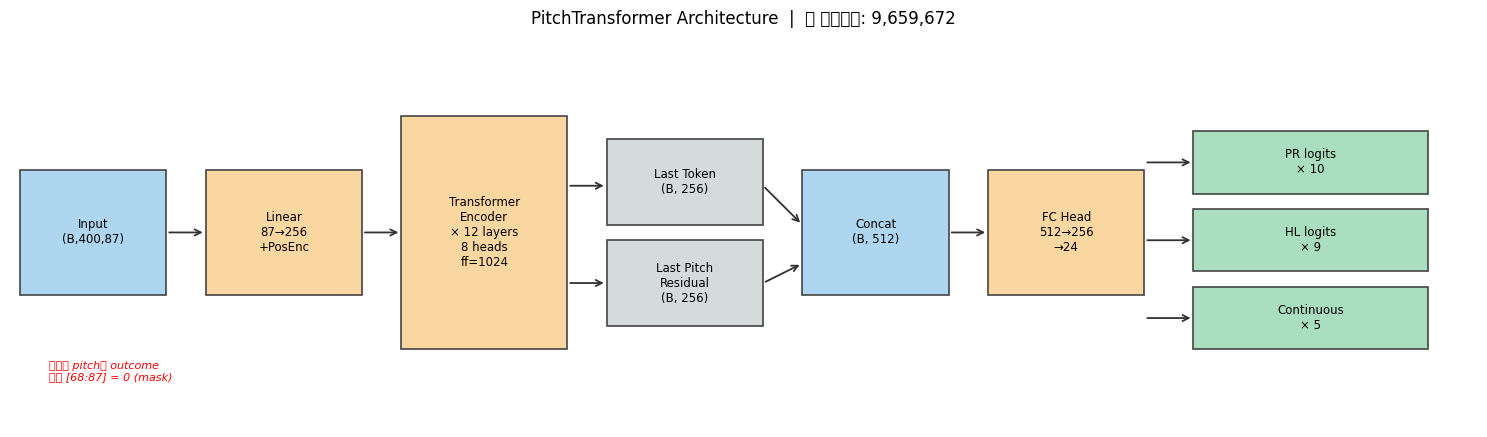

In [2]:
# PitchTransformer 아키텍처 다이어그램
fig, ax = plt.subplots(figsize=(15, 4.5))
ax.set_xlim(0, 15)
ax.set_ylim(0, 5)

boxes = [
    (0.1, 1.7, 1.5, 1.6, 'Input\n(B,400,87)', '#AED6F1'),
    (2.0, 1.7, 1.6, 1.6, 'Linear\n87→256\n+PosEnc', '#FAD7A0'),
    (4.0, 1.0, 1.7, 3.0, 'Transformer\nEncoder\n× 12 layers\n8 heads\nff=1024', '#FAD7A0'),
    (6.1, 2.6, 1.6, 1.1, 'Last Token\n(B, 256)', '#D5DBDB'),
    (6.1, 1.3, 1.6, 1.1, 'Last Pitch\nResidual\n(B, 256)', '#D5DBDB'),
    (8.1, 1.7, 1.5, 1.6, 'Concat\n(B, 512)', '#AED6F1'),
    (10.0, 1.7, 1.6, 1.6, 'FC Head\n512→256\n→24', '#FAD7A0'),
    (12.1, 3.0, 2.4, 0.8, 'PR logits\n× 10', '#A9DFBF'),
    (12.1, 2.0, 2.4, 0.8, 'HL logits\n× 9', '#A9DFBF'),
    (12.1, 1.0, 2.4, 0.8, 'Continuous\n× 5', '#A9DFBF'),
]

for x, y, w, h, text, color in boxes:
    rect = plt.Rectangle((x, y), w, h, linewidth=1.2,
                          edgecolor='#444', facecolor=color, zorder=2)
    ax.add_patch(rect)
    ax.text(x + w/2, y + h/2, text, ha='center', va='center',
            fontsize=8.5, zorder=3)

# 화살표 (주요 흐름)
arrow_pairs = [
    ((1.6, 2.5), (2.0, 2.5)),   # 입력 → 임베딩
    ((3.6, 2.5), (4.0, 2.5)),   # 임베딩 → Transformer
    ((5.7, 3.1), (6.1, 3.1)),   # Transformer → Last Token
    ((5.7, 1.85), (6.1, 1.85)), # Transformer → Residual
    ((7.7, 3.1), (8.1, 2.6)),   # Last Token → Concat
    ((7.7, 1.85), (8.1, 2.1)),  # Residual → Concat
    ((9.6, 2.5), (10.0, 2.5)),  # Concat → FC
    ((11.6, 3.4), (12.1, 3.4)), # FC → PR
    ((11.6, 2.4), (12.1, 2.4)), # FC → HL
    ((11.6, 1.4), (12.1, 1.4)), # FC → Cont
]

for (x1, y1), (x2, y2) in arrow_pairs:
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle='->', color='#333', lw=1.3), zorder=1)

# Sub-token mask 표시
ax.text(0.4, 0.6, '마지막 pitch의 outcome\n피처 [68:87] = 0 (mask)', fontsize=8,
        color='red', style='italic')

ax.axis('off')
ax.set_title('PitchTransformer Architecture  |  총 파라미터: 9,659,672', fontsize=12, pad=10)
plt.tight_layout()
plt.show()

In [3]:
# 파라미터 수 확인
model = PitchTransformer()

total = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f'총 파라미터: {total:,}')
print(f'학습 가능:   {trainable:,}')

# 컴포넌트별 파라미터
print('\n=== 컴포넌트별 파라미터 수 ===')
components = [
    ('embedding (87→256)', model.embedding),
    ('transformer (12 layers)', model.transformer),
    ('last_pitch_proj (87→256)', model.last_pitch_proj),
    ('fc1 (512→256)', model.fc1),
    ('fc2 (256→24)', model.fc2),
]
for name, mod in components:
    n = sum(p.numel() for p in mod.parameters())
    print(f'  {name:35s}: {n:>10,}  ({n/total*100:5.1f}%)')

총 파라미터: 9,659,672
학습 가능:   9,659,672

=== 컴포넌트별 파라미터 수 ===
  embedding (87→256)                 :     22,528  (  0.2%)
  transformer (12 layers)            :  9,477,120  ( 98.1%)
  last_pitch_proj (87→256)           :     22,528  (  0.2%)
  fc1 (512→256)                      :    131,328  (  1.4%)
  fc2 (256→24)                       :      6,168  (  0.1%)


## 3. 핵심 트릭 1: Sub-token Masking

### 문제: 데이터 누수 (Data Leakage)

87차원 벡터에는 투구 **결과(result 10-dim)** 와 **타구 위치(hit_location 9-dim)**가 포함된다.
시퀀스의 마지막 pitch가 **예측 대상**인데, 만약 그 pitch의 result/hit_location을
입력으로 사용하면 정답이 입력에 포함되는 심각한 데이터 누수가 발생한다.

### 해결: Sub-token Masking

`PitchSequenceDataset.__getitem__`에서 마지막 pitch의
인덱스 `[68:87]`을 0으로 설정한다:

```python
seq[-1, OUTCOME_START:OUTCOME_END] = 0.0  # OUTCOME_START=68, OUTCOME_END=87
```

- 앞선 399개 pitch: 모든 87차원 정상 사용 (과거 결과 포함, 맥락 학습에 활용)
- 마지막 pitch: result(10) + hit_location(9) = 19차원 0으로 마스킹 (데이터 누수 방지)

C:\Users\zpfh1\AppData\Local\Temp\ipykernel_3264\3785146823.py:43: UserWarning: Glyph 51064 (\N{HANGUL SYLLABLE IN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\zpfh1\AppData\Local\Temp\ipykernel_3264\3785146823.py:43: UserWarning: Glyph 45937 (\N{HANGUL SYLLABLE DEG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\zpfh1\AppData\Local\Temp\ipykernel_3264\3785146823.py:43: UserWarning: Glyph 49828 (\N{HANGUL SYLLABLE SEU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\zpfh1\AppData\Local\Temp\ipykernel_3264\3785146823.py:43: UserWarning: Glyph 47560 (\N{HANGUL SYLLABLE MA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\zpfh1\AppData\Local\Temp\ipykernel_3264\3785146823.py:43: UserWarning: Glyph 51648 (\N{HANGUL SYLLABLE JI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\zpfh1\AppData\Local\Temp\ipykernel_3264\3785146823.py:43: UserWarning: Glyph 47561 (\N{HANGUL SYLLABLE MAG}) missing from font(s)

C:\Users\zpfh1\Projects\transition-models\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44221 (\N{HANGUL SYLLABLE GYEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\zpfh1\Projects\transition-models\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44228 (\N{HANGUL SYLLABLE GYE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\zpfh1\Projects\transition-models\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 54980 (\N{HANGUL SYLLABLE HU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\zpfh1\Projects\transition-models\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 45936 (\N{HANGUL SYLLABLE DE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\zpfh1\Projects\transition-models\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: U

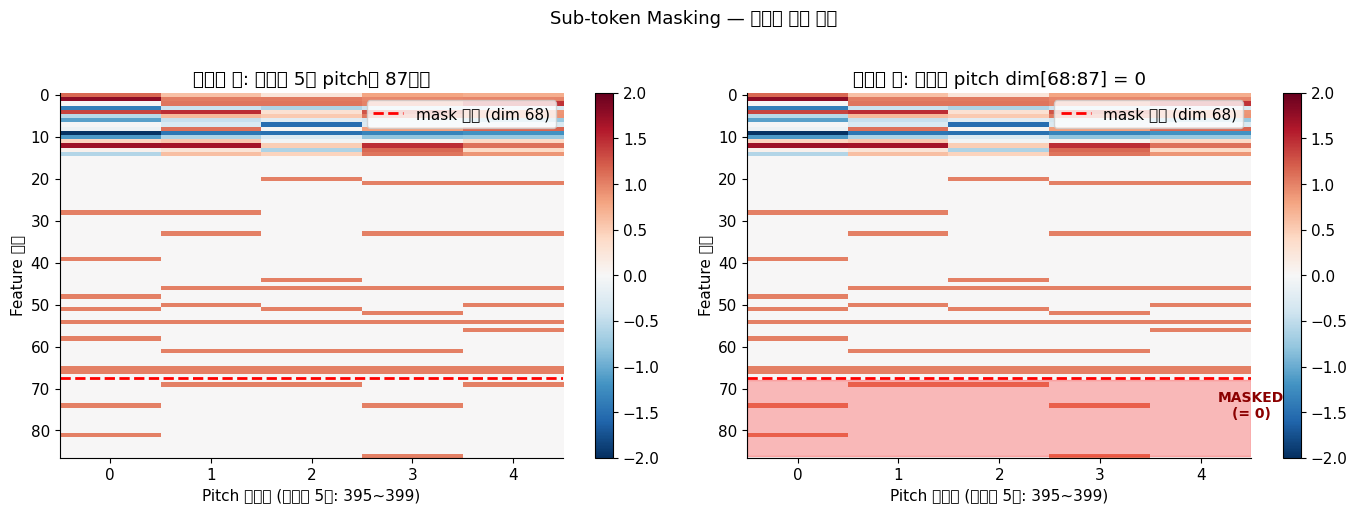

시퀀스 shape: (400, 87)  (400 pitches × 87 features)
마스킹 전 마지막 pitch [68:87] 평균: 0.0526
마스킹 후 마지막 pitch [68:87] 평균: 0.0000  (모두 0)


In [4]:
# Sub-token Masking 시각화
# 실제 데이터로 시퀀스 로드
vecs = np.load('../data/processed/vectors_c_train.npy')
labels = np.load('../data/processed/labels_10_train.npy')
hlocs = np.load('../data/processed/hit_locs_train.npy')
with open('../data/processed/indices_train.pkl', 'rb') as f:
    indices = pickle.load(f)

# 첫 번째 시퀀스 슬라이스 (400, 87)
_, global_start = indices[0]
seq_raw = vecs[global_start:global_start + 400].copy()

# 마스킹 적용
seq_masked = seq_raw.copy()
seq_masked[-1, 68:87] = 0.0

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 마스킹 전 (마지막 pitch)
im0 = axes[0].imshow(seq_raw[-5:].T, aspect='auto', cmap='RdBu_r',
                     vmin=-2, vmax=2, interpolation='nearest')
axes[0].axhline(67.5, color='red', lw=2, ls='--', label='mask 경계 (dim 68)')
axes[0].set_xlabel('Pitch 인덱스 (마지막 5개: 395~399)')
axes[0].set_ylabel('Feature 차원')
axes[0].set_title('마스킹 전: 마지막 5개 pitch의 87차원')
axes[0].legend()
plt.colorbar(im0, ax=axes[0])

# 마스킹 후
im1 = axes[1].imshow(seq_masked[-5:].T, aspect='auto', cmap='RdBu_r',
                     vmin=-2, vmax=2, interpolation='nearest')
axes[1].axhline(67.5, color='red', lw=2, ls='--', label='mask 경계 (dim 68)')
# 마스킹 영역 표시
axes[1].axhspan(68, 86, alpha=0.25, color='red')
axes[1].text(4.5, 77, 'MASKED\n(= 0)', ha='center', color='darkred', fontweight='bold', fontsize=10)
axes[1].set_xlabel('Pitch 인덱스 (마지막 5개: 395~399)')
axes[1].set_ylabel('Feature 차원')
axes[1].set_title('마스킹 후: 마지막 pitch dim[68:87] = 0')
axes[1].legend()
plt.colorbar(im1, ax=axes[1])

plt.suptitle('Sub-token Masking — 데이터 누수 방지', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print(f'시퀀스 shape: {seq_raw.shape}  (400 pitches × 87 features)')
print(f'마스킹 전 마지막 pitch [68:87] 평균: {seq_raw[-1, 68:87].mean():.4f}')
print(f'마스킹 후 마지막 pitch [68:87] 평균: {seq_masked[-1, 68:87].mean():.4f}  (모두 0)')

## 4. 핵심 트릭 2: Last-pitch Residual Connection

### 문제: 정보 희석 (Information Dilution)

12-layer Transformer를 거치면서 마지막 위치의 representation이
앞선 399개 pitch의 정보와 혼합되어 **마지막 pitch의 고유 특성이 희석**될 수 있다.

### 해결: Residual Connection

마지막 pitch의 **원본 87-dim 입력**을 별도 Linear로 투영(87→256)한 뒤,
Transformer 출력의 last token과 **concat**하여 FC head에 전달한다:

```python
last_encoded = encoded[:, -1, :]          # Transformer 출력 last token  (B, 256)
last_raw     = x[:, -1, :]               # 마지막 pitch 원본 입력         (B, 87)
last_proj    = self.last_pitch_proj(last_raw)  # Linear(87→256)          (B, 256)

combined = torch.cat([last_encoded, last_proj], dim=-1)  # (B, 512)
```

이를 통해 FC head는 **시퀀스 맥락(Transformer)** + **현재 투구 특성(Residual)** 두 정보원을 함께 사용한다.

## 5. 핵심 트릭 3: Multi-task Learning

하나의 Transformer로 세 가지 태스크를 **동시에** 학습한다.

| 출력 | 차원 | 타입 | Loss |
|------|-----:|------|------|
| pitch_result | 10 | 분류 | CrossEntropy × 0.7 |
| hit_location | 9 | 분류 (InPlay만) | CrossEntropy × 0.7 |
| continuous | 5 | 회귀 | MSE × 0.3 (현재 placeholder) |

**Total Loss**:
$$\mathcal{L} = 0.7 \cdot \text{CE}_{\text{PR}} + 0.7 \cdot \text{CE}_{\text{HL}} + 0.3 \cdot \text{MSE}_{\text{cont}}$$

**hit_location 마스킹**: InPlay가 아닌 투구는 hit_location 라벨이 -1로 설정되며,
loss 계산 시 `target >= 0`인 샘플만 사용한다.

```python
valid_hl = target_hl >= 0  # InPlay인 샘플만 True
loss_hl = F.cross_entropy(hl_logits[valid_hl], target_hl[valid_hl])
```

Multi-task 학습의 장점: 여러 태스크가 공유 representation을 강제로 풍부하게 만들어
각 태스크의 성능을 향상시키는 효과 (inductive bias).

## 6. 데이터 파이프라인 (Lazy Loading)

### 6.1 Sliding Window

한 타자의 모든 투구를 시간순으로 정렬한 뒤, stride=1로 400 pitch 창을 슬라이딩한다.

```
Batter 665489 (960 pitches 보유):
  window 0: pitch[0..399]
  window 1: pitch[1..400]
  window 2: pitch[2..401]
  ...
  window 560: pitch[560..959]
  → 타자 당 560+1 = 561개 시퀀스 생성
```

전체 유효 시퀀스: Train 521,680 / Val 199,313 / Test 175,862

### 6.2 메모리 비교: Eager vs Lazy Loading

C:\Users\zpfh1\AppData\Local\Temp\ipykernel_3264\823029863.py:47: UserWarning: Glyph 50864 (\N{HANGUL SYLLABLE U}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\zpfh1\AppData\Local\Temp\ipykernel_3264\823029863.py:47: UserWarning: Glyph 47532 (\N{HANGUL SYLLABLE RI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\zpfh1\AppData\Local\Temp\ipykernel_3264\823029863.py:47: UserWarning: Glyph 48169 (\N{HANGUL SYLLABLE BANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\zpfh1\AppData\Local\Temp\ipykernel_3264\823029863.py:47: UserWarning: Glyph 49885 (\N{HANGUL SYLLABLE SIG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\zpfh1\AppData\Local\Temp\ipykernel_3264\823029863.py:47: UserWarning: Glyph 47700 (\N{HANGUL SYLLABLE ME}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\zpfh1\AppData\Local\Temp\ipykernel_3264\823029863.py:47: UserWarning: Glyph 47784 (\N{HANGUL SYLLABLE MO}) missing from font(s) DejaVu

C:\Users\zpfh1\Projects\transition-models\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 47700 (\N{HANGUL SYLLABLE ME}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\zpfh1\Projects\transition-models\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 47784 (\N{HANGUL SYLLABLE MO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\zpfh1\Projects\transition-models\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 47532 (\N{HANGUL SYLLABLE RI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\zpfh1\Projects\transition-models\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 49324 (\N{HANGUL SYLLABLE SA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\zpfh1\Projects\transition-models\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWa

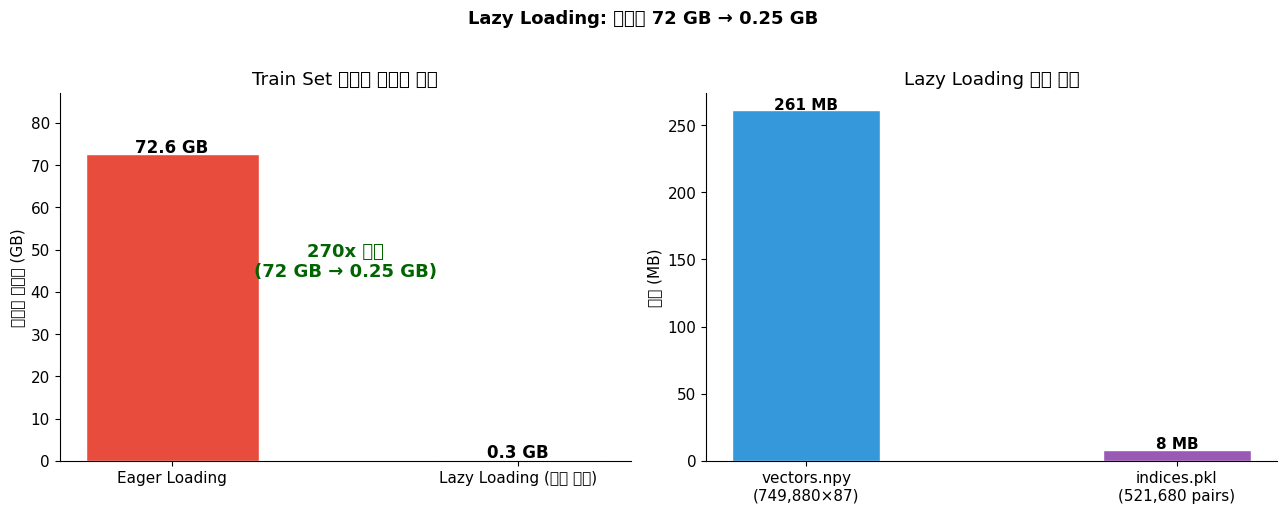

Eager Loading  : 72.6 GB
Lazy Loading   : 261 MB vectors + 8 MB indices = 0.27 GB
메모리 절감: 270배


In [5]:
# Eager vs Lazy Loading 메모리 비교
n_seqs_train = 521_680
seq_len = 400
n_features = 87
bytes_per_float = 4  # float32

# Eager: 모든 시퀀스를 미리 생성
eager_gb = (n_seqs_train * seq_len * n_features * bytes_per_float) / 1e9

# Lazy: 원본 벡터 + 인덱스만 보관
n_rows_train = 749_880  # 전처리된 row 수
lazy_vectors_gb = (n_rows_train * n_features * bytes_per_float) / 1e9
lazy_index_mb = (n_seqs_train * 2 * 8) / 1e6  # (batter_id, start_idx) × int64

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# 메모리 바 비교
methods = ['Eager Loading', 'Lazy Loading (우리 방식)']
values_gb = [eager_gb, lazy_vectors_gb + lazy_index_mb/1000]
colors = ['#E74C3C', '#2ECC71']

bars = axes[0].bar(methods, values_gb, color=colors, width=0.5, edgecolor='white')
for bar, val in zip(bars, values_gb):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{val:.1f} GB', ha='center', fontsize=12, fontweight='bold')
axes[0].set_ylabel('메모리 사용량 (GB)')
axes[0].set_title('Train Set 메모리 사용량 비교')
axes[0].set_ylim(0, eager_gb * 1.2)

# 절감 효과
reduction = eager_gb / (lazy_vectors_gb + lazy_index_mb/1000)
axes[0].text(0.5, eager_gb * 0.6,
             f'{reduction:.0f}x 절감\n(72 GB → 0.25 GB)',
             ha='center', color='darkgreen', fontsize=13, fontweight='bold')

# Lazy Loading 구성 상세
lazy_components = ['vectors.npy\n(749,880×87)', 'indices.pkl\n(521,680 pairs)']
lazy_sizes_mb = [lazy_vectors_gb * 1000, lazy_index_mb]
axes[1].bar(lazy_components, lazy_sizes_mb, color=['#3498DB', '#9B59B6'],
            width=0.4, edgecolor='white')
for i, (name, val) in enumerate(zip(lazy_components, lazy_sizes_mb)):
    axes[1].text(i, val + 1, f'{val:.0f} MB', ha='center', fontsize=11, fontweight='bold')
axes[1].set_ylabel('크기 (MB)')
axes[1].set_title('Lazy Loading 구성 요소')

plt.suptitle('Lazy Loading: 메모리 72 GB → 0.25 GB', fontsize=13, y=1.02, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Eager Loading  : {eager_gb:.1f} GB')
print(f'Lazy Loading   : {lazy_vectors_gb*1000:.0f} MB vectors + {lazy_index_mb:.0f} MB indices'
      f' = {lazy_vectors_gb + lazy_index_mb/1000:.2f} GB')
print(f'메모리 절감: {reduction:.0f}배')

## 7. 87차원 Feature 분해

Model C는 Model B(77-dim)에서 inning(9)을 제거하고
result(10) + hit_location(9)을 추가한다.

| 그룹 | 차원 | Model B | Model C | 비고 |
|------|-----:|:-------:|:-------:|------|
| 연속 피처 | 15 | ✓ | ✓ | 정규화 |
| pitch_type | 17 | ✓ | ✓ | one-hot |
| zone | 14 | ✓ | ✓ | one-hot |
| balls | 4 | ✓ | ✓ | one-hot |
| strikes | 3 | ✓ | ✓ | one-hot |
| outs | 3 | ✓ | ✓ | one-hot |
| base | 8 | ✓ | ✓ | one-hot |
| stand | 2 | ✓ | ✓ | one-hot |
| p_throws | 2 | ✓ | ✓ | one-hot |
| **inning** | **9** | **✓** | **✗** | Model B 전용 |
| **result** | **10** | **✗** | **✓** | Model C 전용, 마지막 pitch 마스킹 |
| **hit_location** | **9** | **✗** | **✓** | Model C 전용, 마지막 pitch 마스킹 |
| **합계** | | **77** | **87** | |

C:\Users\zpfh1\AppData\Local\Temp\ipykernel_3264\2270500320.py:41: UserWarning: Glyph 52264 (\N{HANGUL SYLLABLE CA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\zpfh1\AppData\Local\Temp\ipykernel_3264\2270500320.py:41: UserWarning: Glyph 50896 (\N{HANGUL SYLLABLE WEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\zpfh1\AppData\Local\Temp\ipykernel_3264\2270500320.py:41: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\zpfh1\AppData\Local\Temp\ipykernel_3264\2270500320.py:41: UserWarning: Glyph 50672 (\N{HANGUL SYLLABLE YEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\zpfh1\AppData\Local\Temp\ipykernel_3264\2270500320.py:41: UserWarning: Glyph 49549 (\N{HANGUL SYLLABLE SOG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\zpfh1\AppData\Local\Temp\ipykernel_3264\2270500320.py:41: UserWarning: Glyph 54588 (\N{HANGUL SYLLABLE PI}) missing from font(

C:\Users\zpfh1\Projects\transition-models\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 50672 (\N{HANGUL SYLLABLE YEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\zpfh1\Projects\transition-models\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 49549 (\N{HANGUL SYLLABLE SOG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\zpfh1\Projects\transition-models\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44536 (\N{HANGUL SYLLABLE GEU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\zpfh1\Projects\transition-models\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 47353 (\N{HANGUL SYLLABLE RUB}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\zpfh1\Projects\transition-models\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: U

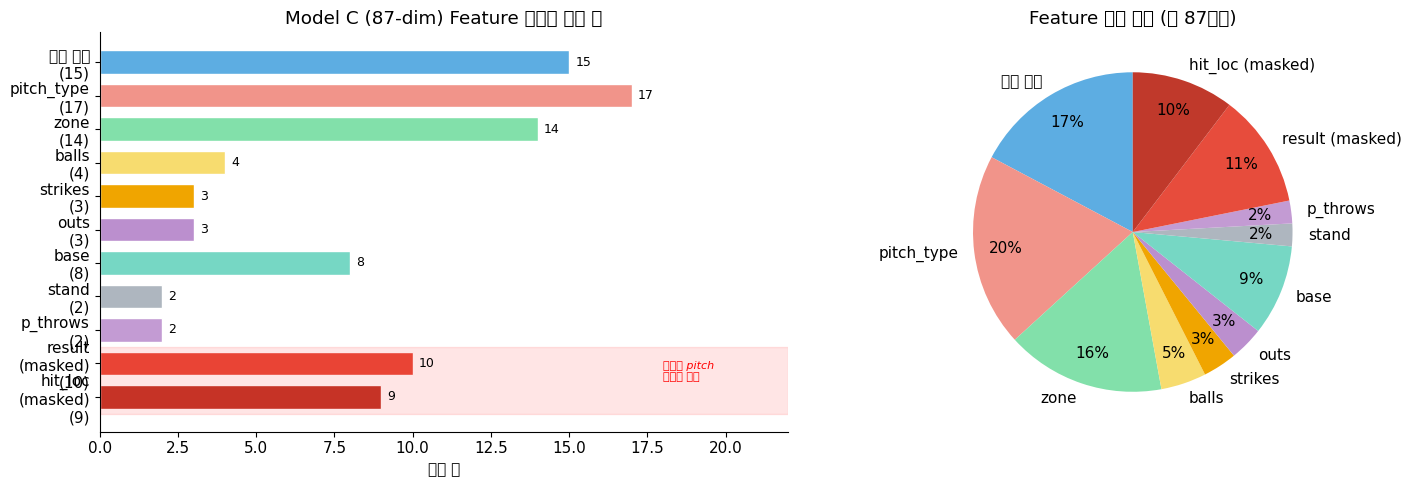

총 차원: 87


In [6]:
# 87차원 Feature 그룹 시각화
groups_c = [
    ('연속 피처', 15, '#5DADE2'),
    ('pitch_type', 17, '#F1948A'),
    ('zone', 14, '#82E0AA'),
    ('balls', 4, '#F7DC6F'),
    ('strikes', 3, '#F0A500'),
    ('outs', 3, '#BB8FCE'),
    ('base', 8, '#76D7C4'),
    ('stand', 2, '#AEB6BF'),
    ('p_throws', 2, '#C39BD3'),
    ('result\n(masked)', 10, '#E74C3C'),
    ('hit_loc\n(masked)', 9, '#C0392B'),
]

labels_c = [f'{g[0]}\n({g[1]})' for g in groups_c]
sizes_c = [g[1] for g in groups_c]
colors_c = [g[2] for g in groups_c]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 수평 막대
bars = axes[0].barh(labels_c[::-1], sizes_c[::-1], color=colors_c[::-1],
                    edgecolor='white', height=0.7)
for bar, size in zip(bars, sizes_c[::-1]):
    axes[0].text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
                 str(size), va='center', fontsize=9)
axes[0].set_xlabel('차원 수')
axes[0].set_title('Model C (87-dim) Feature 그룹별 차원 수')
axes[0].set_xlim(0, 22)

# 빨간 박스로 마스킹 영역 강조
axes[0].axhspan(-0.5, 1.5, alpha=0.1, color='red')
axes[0].text(18, 0.5, '마지막 pitch\n마스킹 영역', fontsize=8, color='red', style='italic')

# 파이 차트
axes[1].pie(sizes_c, labels=[g[0].replace('\n', ' ') for g in groups_c],
            colors=colors_c, autopct='%1.0f%%', startangle=90, pctdistance=0.8)
axes[1].set_title('Feature 그룹 비율 (총 87차원)')

plt.tight_layout()
plt.show()
print(f'총 차원: {sum(sizes_c)}')

## 8. 10-class 라벨 분포

Model C는 Model B의 4-class에서 **10-class**로 확장한다.
InPlay를 세분화하여 MDP 보상 계산에 더 유용한 정보를 제공한다.

| 클래스 | 이름 | 정의 |
|--------|------|------|
| 0 | Ball | 볼, 자동 볼, Pitchout |
| 1 | Strike | 삼진 제외한 스트라이크, Foul(4-class에선 별도) |
| 2 | Single | 1루타 |
| 3 | Double | 2루타 |
| 4 | Triple | 3루타 |
| 5 | HomeRun | 홈런 |
| 6 | FieldOut | 타구 아웃 (땅볼/뜬공/희생번트 등) |
| 7 | Strikeout | 삼진 |
| 8 | Walk | 볼넷 (고의사구, 포수방해 포함) |
| 9 | HitByPitch | 사구 |

C:\Users\zpfh1\AppData\Local\Temp\ipykernel_3264\2878899780.py:39: UserWarning: Glyph 49368 (\N{HANGUL SYLLABLE SAEM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\zpfh1\AppData\Local\Temp\ipykernel_3264\2878899780.py:39: UserWarning: Glyph 54540 (\N{HANGUL SYLLABLE PEUL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\zpfh1\AppData\Local\Temp\ipykernel_3264\2878899780.py:39: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\zpfh1\AppData\Local\Temp\ipykernel_3264\2878899780.py:39: UserWarning: Glyph 46972 (\N{HANGUL SYLLABLE RA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\zpfh1\AppData\Local\Temp\ipykernel_3264\2878899780.py:39: UserWarning: Glyph 48296 (\N{HANGUL SYLLABLE BEL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\zpfh1\AppData\Local\Temp\ipykernel_3264\2878899780.py:39: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missing from font

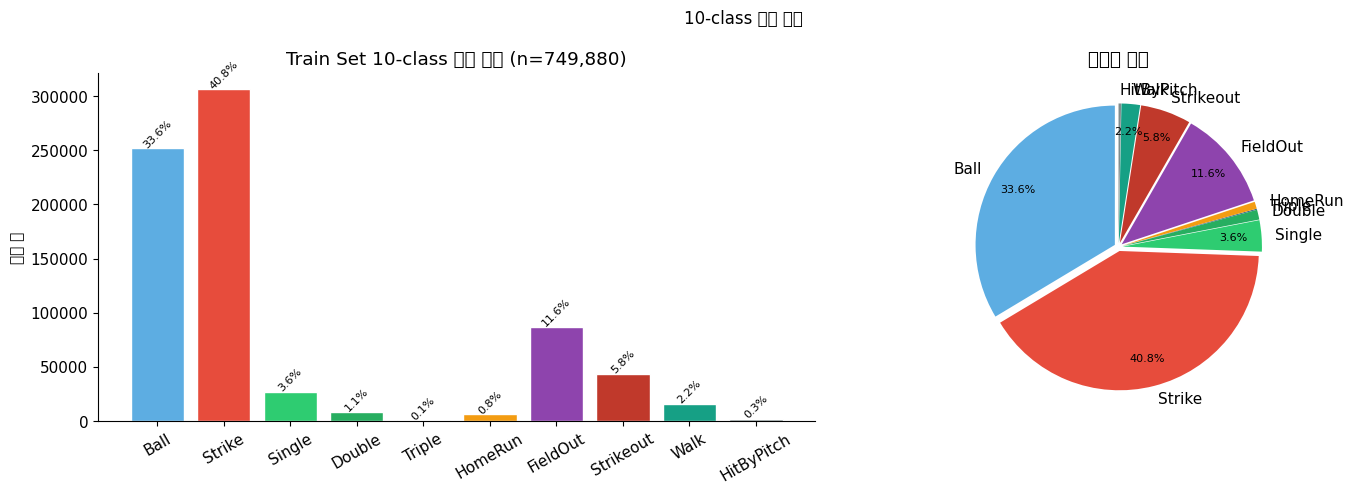

=== 클래스별 통계 ===
Ball        : 252,010 ( 33.6%)  ████████████████
Strike      : 306,082 ( 40.8%)  ████████████████████
Single      :  27,147 (  3.6%)  █
Double      :   8,581 (  1.1%)  
Triple      :     749 (  0.1%)  
HomeRun     :   6,118 (  0.8%)  
FieldOut    :  87,009 ( 11.6%)  █████
Strikeout   :  43,823 (  5.8%)  ██
Walk        :  16,149 (  2.2%)  █
HitByPitch  :   2,212 (  0.3%)  


In [7]:
# 10-class 라벨 분포 시각화
labels_10 = np.load('../data/processed/labels_10_train.npy')

class_names_10 = [
    'Ball', 'Strike', 'Single', 'Double', 'Triple',
    'HomeRun', 'FieldOut', 'Strikeout', 'Walk', 'HitByPitch'
]
class_colors_10 = [
    '#5DADE2', '#E74C3C', '#2ECC71', '#27AE60', '#1A5276',
    '#F39C12', '#8E44AD', '#C0392B', '#16A085', '#7F8C8D'
]

unique, counts = np.unique(labels_10, return_counts=True)
total = counts.sum()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 막대 그래프 (log scale — Triple/HBP가 너무 적어서)
bars = axes[0].bar(class_names_10, counts, color=class_colors_10, edgecolor='white')
for bar, cnt in zip(bars, counts):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
                 f'{cnt/total*100:.1f}%', ha='center', fontsize=8, rotation=45)
axes[0].set_ylabel('샘플 수')
axes[0].set_title('Train Set 10-class 라벨 분포 (n=749,880)')
axes[0].tick_params(axis='x', rotation=30)

# 파이 차트
explode = [0.03] * 10
wedges, texts, autotexts = axes[1].pie(
    counts, labels=class_names_10, colors=class_colors_10,
    autopct=lambda p: f'{p:.1f}%' if p > 2 else '',
    startangle=90, pctdistance=0.8, explode=explode
)
for t in autotexts:
    t.set_fontsize(8)
axes[1].set_title('클래스 비율')

plt.suptitle('10-class 라벨 분포', fontsize=12)
plt.tight_layout()
plt.show()

print('=== 클래스별 통계 ===')
for name, cnt in zip(class_names_10, counts):
    bar_len = int(cnt / total * 50)
    print(f'{name:12s}: {cnt:7,} ({cnt/total*100:5.1f}%)  {"█" * bar_len}')

## 9. 모델 코드 Walkthrough

`src/models/transformer.py`의 핵심 구조:

```python
class PitchTransformer(TransitionModel):
    def __init__(self, input_dim=87, d_model=256, nhead=8, num_layers=12,
                 dim_feedforward=1024, dropout=0.1, max_seq_len=400, ...):

        # 1. 입력 임베딩: 87 → d_model
        self.embedding = nn.Linear(input_dim, d_model)

        # 2. 사인파 Positional Encoding (학습 불필요)
        self.pos_encoding = SinusoidalPositionalEncoding(d_model, max_seq_len)

        # 3. Transformer Encoder 12층
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=256, nhead=8, dim_feedforward=1024,
            dropout=0.1, activation='relu', batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=12)

        # 4. Last-pitch Residual: 87 → d_model (별도 Linear)
        self.last_pitch_proj = nn.Linear(input_dim, d_model)

        # 5. FC Head: concat(256, 256) → 256 → 24
        self.fc1 = nn.Linear(d_model * 2, d_model)
        self.fc2 = nn.Linear(d_model, 24)

    def forward(self, x):  # x: (B, 400, 87)
        embedded  = self.pos_encoding(self.embedding(x))     # (B, 400, 256)
        encoded   = self.transformer(embedded)               # (B, 400, 256)
        last_enc  = encoded[:, -1, :]                        # (B, 256)
        last_proj = self.last_pitch_proj(x[:, -1, :])        # (B, 256)
        combined  = torch.cat([last_enc, last_proj], dim=-1) # (B, 512)
        h = F.relu(self.fc1(combined))
        return self.fc2(h)                                   # (B, 24)
```

**SinusoidalPositionalEncoding**: Vaswani et al. 2017의 고정 사인파 인코딩.
위치 i, 차원 2k에 대해 $\sin(i / 10000^{2k/d})$, 2k+1에 대해 $\cos(i / 10000^{2k/d})$.
학습 파라미터 없이 400 pitch의 시간 순서 정보를 인코딩한다.

C:\Users\zpfh1\AppData\Local\Temp\ipykernel_3264\3509697712.py:31: UserWarning: Glyph 50948 (\N{HANGUL SYLLABLE WI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


C:\Users\zpfh1\AppData\Local\Temp\ipykernel_3264\3509697712.py:31: UserWarning: Glyph 52824 (\N{HANGUL SYLLABLE CI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\zpfh1\AppData\Local\Temp\ipykernel_3264\3509697712.py:31: UserWarning: Glyph 52264 (\N{HANGUL SYLLABLE CA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\zpfh1\AppData\Local\Temp\ipykernel_3264\3509697712.py:31: UserWarning: Glyph 50896 (\N{HANGUL SYLLABLE WEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\zpfh1\AppData\Local\Temp\ipykernel_3264\3509697712.py:31: UserWarning: Glyph 51064 (\N{HANGUL SYLLABLE IN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\zpfh1\AppData\Local\Temp\ipykernel_3264\3509697712.py:31: UserWarning: Glyph 53076 (\N{HANGUL SYLLABLE KO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\zpfh1\AppData\Local\Temp\ipykernel_3264\3509697712.py:31: UserWarning: Glyph 46377 (\N{HANGUL SYLLABLE DING}) missing from font(s

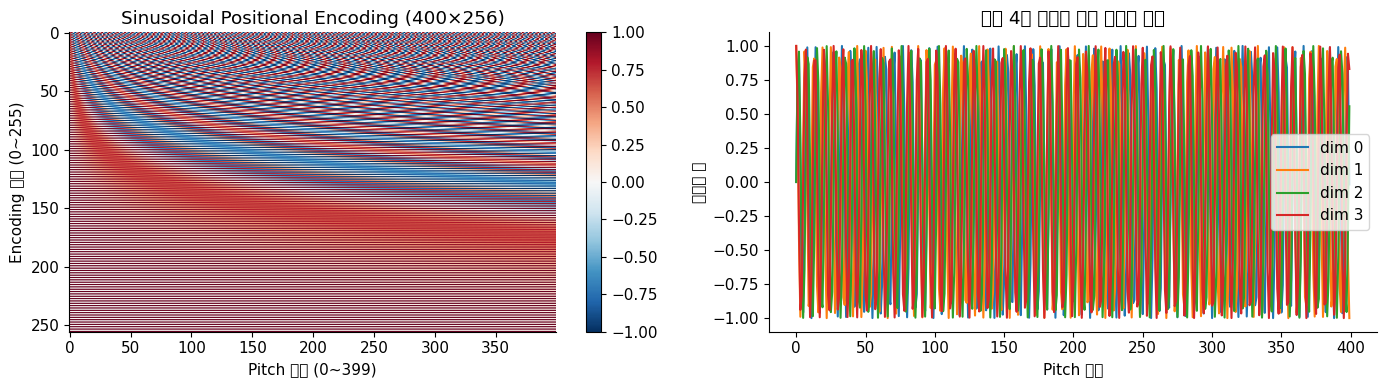

주파수가 높은 차원(dim 0~1): 짧은 주기로 인접 pitch를 구별
주파수가 낮은 차원(dim 252~255): 긴 주기로 전체 시퀀스 내 위치를 표현


In [8]:
# Positional Encoding 시각화
import math

d_model = 256
max_len = 400

pe = torch.zeros(max_len, d_model)
position = torch.arange(0, max_len).unsqueeze(1).float()
div_term = torch.exp(torch.arange(0, d_model, 2).float() * -(math.log(10000.0) / d_model))
pe[:, 0::2] = torch.sin(position * div_term)
pe[:, 1::2] = torch.cos(position * div_term)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# 전체 PE 히트맵
im = axes[0].imshow(pe.numpy().T, aspect='auto', cmap='RdBu_r',
                    vmin=-1, vmax=1)
axes[0].set_xlabel('Pitch 위치 (0~399)')
axes[0].set_ylabel('Encoding 차원 (0~255)')
axes[0].set_title('Sinusoidal Positional Encoding (400×256)')
plt.colorbar(im, ax=axes[0])

# 첫 4개 차원의 패턴
for dim in range(4):
    axes[1].plot(pe[:, dim].numpy(), label=f'dim {dim}')
axes[1].set_xlabel('Pitch 위치')
axes[1].set_ylabel('인코딩 값')
axes[1].set_title('처음 4개 차원의 위치 인코딩 패턴')
axes[1].legend()

plt.tight_layout()
plt.show()
print('주파수가 높은 차원(dim 0~1): 짧은 주기로 인접 pitch를 구별')
print('주파수가 낮은 차원(dim 252~255): 긴 주기로 전체 시퀀스 내 위치를 표현')

## 10. 학습 설정

| 항목 | 값 | 이유 |
|------|-----|------|
| Optimizer | AdamW | weight decay 지원 |
| Learning Rate | 1e-4 | Transformer는 낮은 LR 권장 |
| Weight Decay | 1e-5 | 과적합 억제 |
| Batch Size | 32 | VRAM 8GB (RTX 4070) 제약 |
| Scheduler | CosineAnnealingLR | 전체 step에 걸쳐 감소 |
| Max Epochs | 30 | 데이터 크기 감안 |
| Early Stopping | patience=5 | val loss 기준 |
| Loss | 0.7×CE_PR + 0.7×CE_HL + 0.3×MSE | Multi-task |
| Device | CUDA (RTX 4070) | |

**Epoch당 예상 소요 시간**: 15~30분 (16,303 batches × 32 samples)

**학습 스크립트**: `scripts/09_train_model_c.py`

**배치 당 메모리**:
- 시퀀스: 32 × 400 × 87 × 4 bytes = 446 MB
- 모델 파라미터: ~37 MB (float32)
- Gradient: ~37 MB
- Optimizer state: ~74 MB (AdamW는 파라미터의 2배)
- 총 추정: ~600 MB (RTX 4070 8GB 내 여유)

## 11. 결과 (TODO: 학습 완료 후 채울 자리)

> **학습 진행 중.** `scripts/09_train_model_c.py`가 실행 중이며,
> 완료 후 아래 표를 채울 것.

| Epoch | Train Loss | Val Loss | PR Acc | HL Acc |
|-------|-----------|---------|--------|--------|
| 1 | — | — | — | — |
| ... | — | — | — | — |
| Best | — | **—** | — | — |

- **Best val loss**: TODO
- **PR val accuracy**: TODO
- **HL val accuracy** (InPlay 한정): TODO
- **조기 종료 epoch**: TODO
- **총 학습 시간**: TODO
- **W&B Run**: [model_c_full_v1](https://wandb.ai/pitcheezy/transition-models)

### Model B vs Model C 비교 (예비)

| 지표 | Model B | Model C |
|------|---------|--------|
| Val Loss | 0.8730 | TODO |
| Val Accuracy | 60.6% | TODO |
| 파라미터 | 27,012 | 9,659,672 |
| 입력 | 단일 pitch | 400 pitch 시퀀스 |
| 학습 시간 | 8분 | 예상 2-3시간 |

## 12. 논문과의 차이점

| 항목 | 논문 (MIT Sloan 2025) | 본 구현 |
|------|----------------------|--------|
| Continuous target | 실제 회귀값 (발사각도 등) | 0 placeholder (미구현) |
| Class imbalance | 언급 없음 | 미처리 (향후 weighted loss) |
| 데이터 로딩 | 방식 미공개 | **Lazy Loading 추가** (72 GB → 1 GB) |
| Stride | 1 (논문 명시) | 1 (동일) |
| 시퀀스 길이 | 400 | 400 (동일) |
| d_model | 256 | 256 (동일) |
| Encoder layers | 12 | 12 (동일) |
| Attention heads | 8 | 8 (동일) |
| Loss weights | 미공개 | 0.7/0.7/0.3 (설계 결정) |

### Lazy Loading — 본 프로젝트의 기여

논문에는 데이터 로딩 방식이 명시되지 않았다.
전처리된 벡터를 `np.ndarray`로 저장하고, `__getitem__`에서
`O(1)` numpy 슬라이싱으로 시퀀스를 조립하는 방식으로
메모리 72 GB를 1 GB로 줄였다. 이는 일반 PC에서의 재현성을 크게 높인다.

---

*다음 노트북: [05_comparison.ipynb](05_comparison.ipynb) — 세 모델 최종 비교 (Phase 6)*